# Day 2 — Part 1: Problem Setup and Data

Welcome to Day 2! Today we go from theory to **building a real AI agent**.
In this notebook we frame the problem, define the data contract (schema),
and prepare our service catalog for use by the agent.

---

## What You'll Learn

1. How to frame a real-world problem as a structured AI task
2. How to define a strict input/output schema — the "contract" between data and model
3. How to clean and normalize a dataset for AI retrieval
4. How to identify data quality issues before they cause agent failures
5. What an ideal agent input/output pair looks like

---

## Key Vocabulary

| Term | Simple Explanation |
|------|-------------------|
| **Schema** | A strict blueprint — it defines exactly what fields a response must have |
| **Normalization** | Cleaning data so it's in a consistent, predictable format |
| **Jurisdiction** | Which level of government handles something (City, Region, Province, Federal) |
| **Retrieval text** | A combined searchable string we create from multiple fields in a row |
| **Artifact** | A file produced by a pipeline step — saved for the next step to use |
| **Ground truth** | The correct answer we compare AI predictions against |

## The Challenge

Residents in **Kitchener and Waterloo Region** often don't know which level
of government handles a given service. Should they call the City? The Region?
Contact the Province or even the Federal government?

Our mission: build an AI agent that takes a free-text resident question and returns
a structured JSON response identifying the right jurisdiction and next steps.

**Analogy:** Think of this like a very knowledgeable receptionist at a multi-floor
government building. The resident walks in confused — the receptionist quickly
figures out the right floor and office to send them to.

**Task type:** This is a *hybrid* machine learning task:
- **Classification** — which jurisdiction level?
- **Retrieval** — which specific service in the catalog matches?
- **Generation** — produce a helpful, grounded explanation

## Step 1: Imports and Setup

In [1]:
import sys
from pathlib import Path
import json
import warnings
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')  # Keep output clean for reading
sns.set_style('whitegrid')

# Navigate from notebooks/day2/ up to the project root
ROOT = Path.cwd()
while not (ROOT / 'data').exists() and ROOT.parent != ROOT:
    ROOT = ROOT.parent

# Add root to path so we can import our src/ modules
sys.path.insert(0, str(ROOT))

DATA_DIR = ROOT / 'data'
EVAL_DIR = ROOT / 'eval'
ARTIFACTS_DIR = ROOT / 'artifacts'
ARTIFACTS_DIR.mkdir(exist_ok=True)

print(f'Project root: {ROOT.resolve()}')
print(f'Data files:   {[p.name for p in DATA_DIR.iterdir()]}')
print(f'Eval files:   {[p.name for p in EVAL_DIR.iterdir()]}')

Project root: D:\Projects\AI_Agent_Workshop
Data files:   ['service_catalog.csv', 'service_catalog.json']
Eval files:   ['service_eval_set.csv']


## Step 2: Define the Output Schema

Before we touch any data or write any AI code, we define the **contract** —
the exact shape of every response the agent must produce.

**Why first?** Just like a chef reads the full recipe before starting to cook,
defining the schema first prevents mismatches between what the agent produces
and what downstream code expects.

In [2]:
from src.schema import RESPONSE_SCHEMA, RESPONSE_JSON_SCHEMA, validate_response

print('Response schema fields:')
for field, description in RESPONSE_SCHEMA.items():
    print(f'  {field:25s}  {description}')

Response schema fields:
  service_name               string — canonical service name from the catalog
  jurisdiction_level         City | Region | Province | Federal | Mixed | Unclear
  responsible_body           string — name of the government body
  confidence                 float in [0.0, 1.0]
  reasoning_summary          string — short grounded explanation (1-3 sentences)
  next_steps                 ['step 1 (string)', 'step 2 (string)']
  sources                    ['url_1 (string)', 'url_2 (string)']


In [3]:
# Test the validator with a GOOD example
ideal_response = {
    'service_name': 'garbage pickup',
    'jurisdiction_level': 'Region',
    'responsible_body': 'Region of Waterloo Waste Management',
    'confidence': 0.95,
    'reasoning_summary': (
        'Curbside garbage collection in Kitchener is managed by the Region of Waterloo '
        'Waste Management division, not the City itself. '
        'Residents should contact the Region for missed collections or bin replacements.'
    ),
    'next_steps': [
        'Report missed pickup at regionofwaterloo.ca/waste',
        'Call Region of Waterloo at 519-575-4400'
    ],
    'sources': ['https://www.regionofwaterloo.ca/en/living-here/waste-management.aspx']
}

is_valid, errors = validate_response(ideal_response)
print(f'Valid: {is_valid}')
print(f'Errors: {errors}')

Valid: True
Errors: []


In [4]:
# Test the validator with a BAD example — to see what errors look like
bad_response = {
    'service_name': 'garbage pickup',
    'jurisdiction_level': 'Municipal',   # Not a valid enum value!
    'responsible_body': 'City Hall',
    # Missing: confidence, reasoning_summary, next_steps, sources
}

is_valid, errors = validate_response(bad_response)
print(f'Valid: {is_valid}')
print('Validation errors:')
for err in errors:
    print(f'  - {err}')

Valid: False
Validation errors:
  - Missing required field: 'confidence'
  - Missing required field: 'reasoning_summary'
  - Missing required field: 'next_steps'
  - Missing required field: 'sources'
  - Invalid jurisdiction_level 'Municipal'. Must be one of: {'Unclear', 'Federal', 'Mixed', 'Region', 'City', 'Province'}


**What do we see here?**

- The validator catches two types of errors: **missing fields** and **invalid values**
- `'Municipal'` is rejected because our schema only accepts the 6 valid jurisdiction levels
- This is exactly how we'll validate every agent response in the evaluation pipeline
- Building schema validation *before* the agent means we can catch bugs early

## Step 3: Load and Inspect the Service Catalog

In [5]:
catalog_raw = pd.read_csv(DATA_DIR / 'service_catalog.csv')
print(f'Catalog shape: {catalog_raw.shape}  ({catalog_raw.shape[0]} services)')
catalog_raw.head()

Catalog shape: (15, 7)  (15 services)


,service_name,jurisdiction_level,responsible_body,description,keywords,next_steps_hint,source_url
0,garbage pickup,Region,Region of Waterloo Waste Management,"Residential garbage collection schedule, misse...",garbage;waste;pickup;missed collection;curbside,Check the regional waste collection schedule; ...,https://www.regionofwaterloo.ca/
1,recycling collection,Region,Region of Waterloo Waste Management,Blue box recycling collection and schedule inf...,recycling;blue box;collection,Check the regional collection calendar and rec...,https://www.regionofwaterloo.ca/
2,property tax billing,City,City of Kitchener Revenue Division,"Property tax billing, payment options, and acc...",property tax;tax bill;billing;assessment,Visit the city's property tax page or contact ...,https://www.kitchener.ca/
3,water billing,City,City of Kitchener Utilities,Water billing and account inquiries for city u...,water bill;utilities;billing,Check your city utility account and payment op...,https://www.kitchener.ca/
4,snow removal on regional roads,Region,Region of Waterloo Transportation Services,Maintenance and snow clearing for regional roads.,snow removal;plowing;regional roads;winter mai...,Confirm whether the road is regional before co...,https://www.regionofwaterloo.ca/


In [6]:
catalog_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   service_name        15 non-null     str  
 1   jurisdiction_level  15 non-null     str  
 2   responsible_body    15 non-null     str  
 3   description         15 non-null     str  
 4   keywords            15 non-null     str  
 5   next_steps_hint     15 non-null     str  
 6   source_url          15 non-null     str  
dtypes: str(7)
memory usage: 972.0 bytes


In [7]:
# Check for missing values — any NaN means the agent might fail for that row
missing = catalog_raw.isnull().sum()
print('Missing values per column:')
print(missing[missing > 0] if missing.any() else 'None — catalog is complete!')

Missing values per column:
None — catalog is complete!


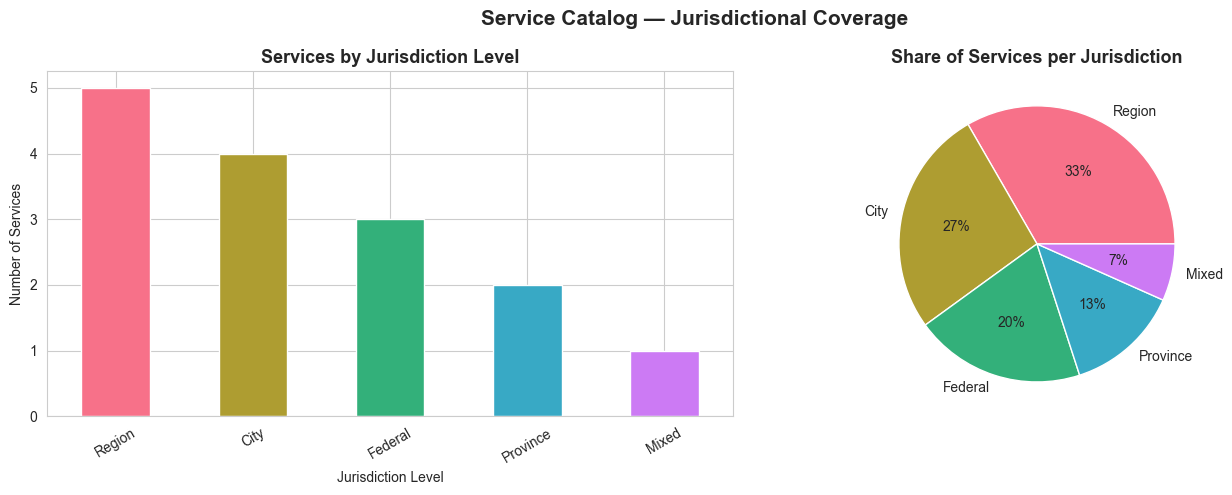

In [8]:
# Visualize jurisdiction distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

counts = catalog_raw['jurisdiction_level'].value_counts()
counts.plot(kind='bar', ax=axes[0], color=sns.color_palette('husl', len(counts)))
axes[0].set_title('Services by Jurisdiction Level', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Jurisdiction Level')
axes[0].set_ylabel('Number of Services')
axes[0].tick_params(axis='x', rotation=30)

counts.plot(kind='pie', ax=axes[1], autopct='%1.0f%%',
            colors=sns.color_palette('husl', len(counts)))
axes[1].set_title('Share of Services per Jurisdiction', fontsize=13, fontweight='bold')
axes[1].set_ylabel('')

plt.suptitle('Service Catalog — Jurisdictional Coverage', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

**What do we see here?**

- The catalog covers all key jurisdiction levels: City, Region, Province, Federal
- There is at least one **Mixed** service (public transit) — this is intentionally ambiguous
- No jurisdiction level dominates overwhelmingly, which is good for evaluation diversity
- Any level with very few examples will be harder for the agent to learn from —
  adding more examples for underrepresented jurisdictions would improve performance

## Step 4: Normalize the Catalog

Raw CSV data has messy formatting (mixed case, extra spaces, semicolons in keywords).
We normalize it to create three extra helper columns that make retrieval much easier.

**Analogy:** Think of normalization like sorting a messy library.
All book titles go to lowercase, keywords are split out individually,
and each book gets a single searchable description string.
The library is the same — it's just easier to search now.

In [9]:
from src.retrieval import normalize_catalog

catalog = normalize_catalog(catalog_raw)

print('New columns added:')
for col in ['service_name_normalized', 'keywords_list', 'retrieval_text']:
    print(f'  {col}')

# Preview the new fields
catalog[['service_name', 'service_name_normalized', 'keywords_list', 'retrieval_text']].head(3)

New columns added:
  service_name_normalized
  keywords_list
  retrieval_text


,service_name,service_name_normalized,keywords_list,retrieval_text
0,garbage pickup,garbage pickup,"[garbage, waste, pickup, missed collection, cu...",garbage pickup | residential garbage collectio...
1,recycling collection,recycling collection,"[recycling, blue box, collection]",recycling collection | blue box recycling coll...
2,property tax billing,property tax billing,"[property tax, tax bill, billing, assessment]","property tax billing | property tax billing, p..."


In [10]:
# Full sorted view — grouped by jurisdiction level
catalog[['service_name', 'jurisdiction_level', 'responsible_body']].sort_values(
    by=['jurisdiction_level', 'service_name']
).reset_index(drop=True)

,service_name,jurisdiction_level,responsible_body
0,property tax billing,City,City of Kitchener Revenue Division
1,road pothole on local street,City,City of Kitchener Transportation Services
2,snow removal on city streets,City,City of Kitchener Operations
3,water billing,City,City of Kitchener Utilities
4,employment insurance,Federal,Government of Canada
5,income tax filing,Federal,Canada Revenue Agency
6,passport services,Federal,Government of Canada
7,public transit,Mixed,Grand River Transit / Regional municipality co...
8,child care subsidies,Province,Government of Ontario
9,drivers licence renewal,Province,Government of Ontario / ServiceOntario


**What do we see here?**

- Every service is now neatly organized by jurisdiction level
- The `retrieval_text` column combines name + description + keywords into one searchable string
- This is exactly what `keyword_retrieve()` will search over in the agent notebooks
- Notice **snow removal appears twice** — once for city streets, once for regional roads.
  This is a real ambiguity: the agent must learn to distinguish them from the question.

## Step 5: Data Quality Checks

In [11]:
VALID_JURISDICTIONS = {'City', 'Region', 'Province', 'Federal', 'Mixed', 'Unclear'}

# Check 1: All jurisdiction levels must be valid
invalid_jl = catalog[~catalog['jurisdiction_level'].isin(VALID_JURISDICTIONS)]
print(f'Rows with invalid jurisdiction_level: {len(invalid_jl)}')

# Check 2: No empty service names
empty_names = catalog[catalog['service_name'].isna() | (catalog['service_name'].str.strip() == '')]
print(f'Rows with empty service_name:         {len(empty_names)}')

# Check 3: No empty responsible bodies
empty_body = catalog[catalog['responsible_body'].isna() | (catalog['responsible_body'].str.strip() == '')]
print(f'Rows with empty responsible_body:     {len(empty_body)}')

# Check 4: Keywords column present
missing_kw = catalog[catalog['keywords'].isna()]
print(f'Rows with missing keywords:           {len(missing_kw)}')

print('\nData quality: all checks passed!' if all(len(x)==0 for x in [invalid_jl, empty_names, empty_body, missing_kw]) else '\nData quality: issues found — see above.')

Rows with invalid jurisdiction_level: 0
Rows with empty service_name:         0
Rows with empty responsible_body:     0
Rows with missing keywords:           0

Data quality: all checks passed!


## Step 6: Exercise — Extend the Catalog

We add 3 new services (including 2 intentionally ambiguous examples)
to stress-test the agent's ability to handle edge cases.
One entry is marked as `Unclear` — the correct answer when jurisdiction is genuinely debatable.

In [12]:
# ── 3 new catalog entries ──────────────────────────────────────────────────────
new_services = pd.DataFrame([
    {
        'service_name': 'affordable housing programs',
        'jurisdiction_level': 'Mixed',           # Ambiguous: City + Region + Province all involved
        'responsible_body': 'City of Kitchener / Region of Waterloo Housing Services',
        'description': (
            'Affordable and social housing programs are a shared responsibility. '
            'The Region manages social housing waitlists while the City runs local housing funds.'
        ),
        'keywords': 'affordable housing;social housing;rent subsidy;housing waitlist;low income housing',
        'next_steps_hint': (
            'Contact Region of Waterloo Housing Services for social housing waitlists. '
            'Visit City of Kitchener for local housing programs.'
        ),
        'source_url': 'https://www.regionofwaterloo.ca/en/living-here/housing.aspx'
    },
    {
        'service_name': 'park maintenance and repairs',
        'jurisdiction_level': 'City',            # City maintains local parks
        'responsible_body': 'City of Kitchener Parks and Cemeteries',
        'description': (
            'Maintenance, repairs, and programs for local parks, trails, and green spaces '
            'within Kitchener city limits.'
        ),
        'keywords': 'park;playground;trail;green space;park maintenance;broken bench;graffiti park',
        'next_steps_hint': 'Report park issues through the Kitchener 311 service or kitchener.ca/parks.',
        'source_url': 'https://www.kitchener.ca/en/parks-and-trails.aspx'
    },
    {
        'service_name': 'noise complaints',
        'jurisdiction_level': 'Unclear',         # Unclear: depends on source (construction=City, neighbour=City, event=Region)
        'responsible_body': 'Varies by noise source',
        'description': (
            'Noise complaints depend heavily on context: neighbour noise is a City/bylaw issue; '
            'construction noise may involve Region; event noise can involve either. '
            'Without more context, jurisdiction is unclear.'
        ),
        'keywords': 'noise;loud music;construction noise;neighbour noise;bylaw;noise complaint;sound',
        'next_steps_hint': (
            'For neighbour or construction noise: contact Kitchener Municipal Bylaw at 519-741-2345. '
            'For large events: contact Region at 519-575-4400.'
        ),
        'source_url': 'https://www.kitchener.ca/en/living-here/noise-and-nuisances.aspx'
    },
])

# Add the new rows and re-normalize
from src.retrieval import normalize_catalog
catalog_extended = normalize_catalog(
    pd.concat([catalog_raw, new_services], ignore_index=True)
)

print(f'Original catalog: {len(catalog_raw)} services')
print(f'Extended catalog: {len(catalog_extended)} services')

# Show the new entries
catalog_extended.tail(3)[['service_name', 'jurisdiction_level', 'responsible_body']]

Original catalog: 15 services
Extended catalog: 18 services


,service_name,jurisdiction_level,responsible_body
15,affordable housing programs,Mixed,City of Kitchener / Region of Waterloo Housing...
16,park maintenance and repairs,City,City of Kitchener Parks and Cemeteries
17,noise complaints,Unclear,Varies by noise source


**Key Insight**

- **Ambiguous examples** (Mixed, Unclear) are the hardest for any AI agent
- `affordable housing` is `Mixed` — multiple levels of government share responsibility
- `noise complaints` is `Unclear` — the right answer genuinely depends on context
- Including these in the catalog trains the agent to acknowledge uncertainty
  rather than hallucinating a confident but wrong answer
- In production, these would trigger a **clarifying question** back to the resident

## Step 7: Ideal Input/Output Pair

Before evaluating the agent, let's define what a **perfect response** looks like.
This is the gold standard we measure everything against.

In [13]:
ideal_example = {
    'input': 'Who do I contact about garbage pickup in Kitchener?',
    'ideal_output': {
        'service_name': 'garbage pickup',
        'jurisdiction_level': 'Region',
        'responsible_body': 'Region of Waterloo Waste Management',
        'confidence': 0.97,
        'reasoning_summary': (
            'Curbside garbage and waste collection in Kitchener is managed by the '
            'Region of Waterloo Waste Management division, not the City of Kitchener directly. '
            'The Region handles all residential waste services across Waterloo Region municipalities.'
        ),
        'next_steps': [
            'Report a missed collection at regionofwaterloo.ca/waste',
            'For bin damage or replacement, call 519-575-4400',
            'Check your collection schedule at the Region of Waterloo website'
        ],
        'sources': [
            'https://www.regionofwaterloo.ca/en/living-here/waste-management.aspx'
        ]
    }
}

is_valid, errors = validate_response(ideal_example['ideal_output'])

print('=== IDEAL INPUT ===')
print(ideal_example['input'])
print()
print('=== IDEAL OUTPUT (validates against schema) ===')
print(json.dumps(ideal_example['ideal_output'], indent=2))
print()
print(f'Schema valid: {is_valid}')

=== IDEAL INPUT ===
Who do I contact about garbage pickup in Kitchener?

=== IDEAL OUTPUT (validates against schema) ===
{
  "service_name": "garbage pickup",
  "jurisdiction_level": "Region",
  "responsible_body": "Region of Waterloo Waste Management",
  "confidence": 0.97,
  "reasoning_summary": "Curbside garbage and waste collection in Kitchener is managed by the Region of Waterloo Waste Management division, not the City of Kitchener directly. The Region handles all residential waste services across Waterloo Region municipalities.",
  "next_steps": [
    "Report a missed collection at regionofwaterloo.ca/waste",
    "For bin damage or replacement, call 519-575-4400",
    "Check your collection schedule at the Region of Waterloo website"
  ],
  "sources": [
    "https://www.regionofwaterloo.ca/en/living-here/waste-management.aspx"
  ]
}

Schema valid: True


## Step 8: Export Cleaned Artifacts

In [14]:
output_path = ARTIFACTS_DIR / 'service_catalog.cleaned.json'
catalog_extended.to_json(output_path, orient='records', indent=2)
print(f'Exported {len(catalog_extended)} services to {output_path.resolve()}')

Exported 18 services to D:\Projects\AI_Agent_Workshop\artifacts\service_catalog.cleaned.json


## Step 9: Evaluation Set Preview

In [15]:
eval_df = pd.read_csv(EVAL_DIR / 'service_eval_set.csv')
print(f'Evaluation set: {len(eval_df)} benchmark questions')
eval_df

Evaluation set: 8 benchmark questions


,question,expected_service_name,expected_jurisdiction_level,expected_responsible_body
0,Who do I contact about garbage pickup?,garbage pickup,Region,Region of Waterloo Waste Management
1,Is childcare a city or provincial service?,child care subsidies,Province,Government of Ontario
2,Who handles my property tax bill in Kitchener?,property tax billing,City,City of Kitchener Revenue Division
3,How do I renew my driver's licence?,drivers licence renewal,Province,Government of Ontario / ServiceOntario
4,Where do I apply for EI?,employment insurance,Federal,Government of Canada
5,I found a pothole on my street. Who fixes it?,road pothole on local street,City,City of Kitchener Transportation Services
6,Who clears snow on regional roads?,snow removal on regional roads,Region,Region of Waterloo Transportation Services
7,Who do I call about restaurant inspections?,public health inspections,Region,Region of Waterloo Public Health


**Key Insight — Evaluation Set Design**

- The 8 benchmark questions are designed to test all jurisdiction levels
- Each has a known correct answer (`expected_jurisdiction_level`, `expected_responsible_body`)
- We will use these in Day2_03 to score the agent's performance automatically
- The questions are phrased as a real resident would ask them — informal, sometimes vague
- This realistic phrasing is intentional: the agent must handle natural language, not just exact service names

---

## Reflection: Framing the Problem

| Question | Answer |
|----------|--------|
| Which parts are classification? | Predicting `jurisdiction_level` — 6 possible classes |
| Which parts require retrieval? | Finding the right service record in the catalog |
| Which parts benefit from tool use? | Looking up exact body names, fetching next steps |
| What should be deterministic? | `jurisdiction_level` (exact enum), `service_name` (catalog value), `sources` (real URLs) |
| What can be generative? | `reasoning_summary`, `next_steps` (natural language explanation) |

---

**Now that we've set up our data and schema, let's build the agent in Day2_02!**